In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [2]:
#Q1

def f(x):
    return x**3 / (np.exp(x) - 1)

def simpsons_13(f,x_o,x_n, m):
  N = 2*m + 1
  x = np.linspace(x_o,x_n,N)
  h = x[1] - x[0]
  return (h*(f(x[0]) + f(x[-1]) + 4*np.sum(f(x[1:-1:2])) + 2*np.sum(f(x[2:-1:2])))/3)

def boole(f,x_o,x_n, m):
  N = 4*m + 1
  x = np.linspace(x_o,x_n,N)
  h = x[1] - x[0]
  return (2*h*(7*(f(x[0]) + f(x[-1])) + 32*np.sum(f(x[1:-1:2])) + 12*np.sum(f(x[2:-1:4])) + 14*np.sum(f(x[4:-1:4])))/45)
x0 = 1e-05
xf = 20

print(simpsons_13(f, x0, xf, 10))
print(boole(f, x0, xf, 10))

6.510585254021105
6.49392027281816


In [3]:
#Q2

def V(r):
    potential = 4*((1/r**12) - (1/r**6))
    return potential
    
def F(r):
    derivative = 4*((-12/(r**13)) - (-6/(r**7)))
    return derivative


#defining our error margin and maximum iterations
eps = 1.0E-05
maxiter = 50

def bisection(f,L,R,eps,maxiter):
    #f: function whose roots we are to find
    #L: left interval
    #R: right interval
    c = (L+R)/2
    iteration = 1
    while abs(f(c)) >= eps and iteration < maxiter:
        if f(L)*f(R) > 0:
            print("Bad interval!")
            return None
        if f(L)*f(c) <= 0:
            R = c
        else:
            L = c
        c = (L+R)/2
        iteration += 1
        
    if iteration == maxiter and abs(f(c)) >= eps:
        print("Failed to converge!")
        return None
    else:
        return c, iteration

def secant(f,L,R,eps,maxiter):
    #f: function whose roots we are to find
    #L: left interval
    #R: right interval
    x2,x1 = R,L
    iteration = 1
    while abs(f(x2)) >= eps and iteration < maxiter:
        x3 = x2 - f(x2)*(x2 - x1)/(f(x2) - f(x1))
        x1 = x2
        x2 = x3
        iteration += 1
        
    if iteration == maxiter and abs(f(x2)) >= eps:
        print("Failed to converge!")
        return None
    else:
        return x2, iteration  
    
print(f"The root and number of iteration using Bisection method is {bisection(F,0.5,1.5, eps, maxiter)}") 
print(f"The root and number of iteration using Secant method is {secant(F,1.1,1.25, eps, maxiter)}")    

The root and number of iteration using Bisection method is (1.1224620342254639, 22)
The root and number of iteration using Secant method is (1.1224620488527122, 10)


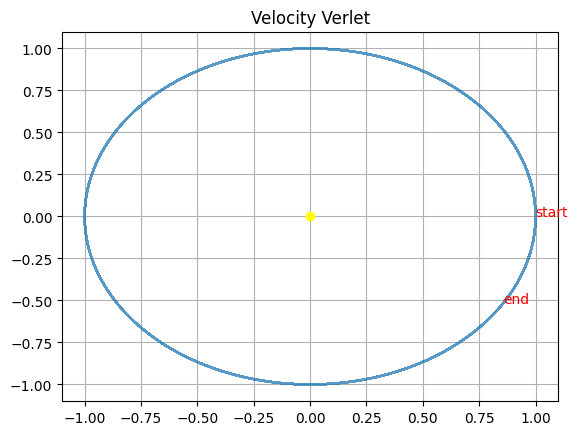

In [4]:
#Q3

GM = 1
m = 1
def force(x, y):
    r = np.sqrt(x**2 + y**2)
    ax = -GM*x/r**3
    ay = -GM*y/r**3
    return ax, ay

def velocity_verlet(xn, vxn, yn, vyn, h):
    ax, ay = force(xn, yn)
    ynp1 = yn + vyn*h + 0.5*ay*(h**2)
    xnp1 = xn + vxn*h + 0.5*ax*(h**2)
    
    ax_new, ay_new = force(xnp1, ynp1)
    
    vynp1 = vyn + 0.5*(ay + ay_new)*h
    vxnp1 = vxn + 0.5*(ax + ax_new)*h
    
    return ynp1, vynp1, xnp1, vxnp1
    
def energy(x, y, vx, vy):
    return 0.5*m*(vx**2 + vy**2) - GM*m/(np.sqrt(x**2 + y**2))

def caller_yv(method, fn, x0, vx0, y0, vy0, N, ts, h):
    
    ys = np.zeros(N)
    vys = np.zeros(N)
    ys[0] = y0
    vys[0] = vy0
    xs = np.zeros(N)
    vxs = np.zeros(N)
    xs[0] = x0
    vxs[0] = vx0
    E = np.zeros(N)
    E[0] = energy(x0, y0, vx0, vy0)
    for i in range(1, N):
        t = ts[i]
        ys[i], vys[i], xs[i], vxs[i]  = method(xs[i-1], vxs[i-1],ys[i-1], vys[i-1], h)
        E[i] = energy(xs[i], ys[i], vxs[i], vys[i])
        
    
    return ys, xs, E

ro = 1
vo = np.sqrt(GM/ro)

h = 1.0e-2
t0 = 0
tf = 100

ts = np.arange(t0, tf, h)
N = len(ts)

# Initial condition 
x0 = ro
y0 = 0
vy0 = vo
vx0 = 0

# Call the methods
y_vv, x_vv, E = caller_yv(velocity_verlet, force, x0, vx0, y0, vy0, N, ts, h)

# Plot for Velocity Verlet method
plt.plot(x_vv, y_vv, alpha = 0.75)
plt.title("Velocity Verlet")
plt.plot(0,0, color = "yellow", marker = "o")
plt.text(x_vv[0], y_vv[0], "start", color = "r")
plt.text(x_vv[-1], y_vv[-1], "end", color = "r")
#plt.plot(ts, E, label = "energy")
#plt.legend()
plt.grid()


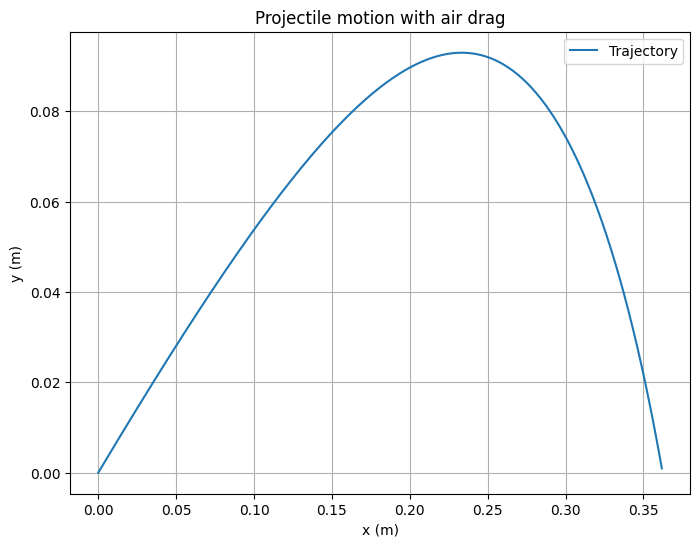

In [5]:
#Q4
C = 5
m = 1
grav = 9.8
v0 = 5
theta = np.radians(30)
x0 = 0
y0 = 0
vx0 = v0*np.cos(theta)
vy0 = v0*np.sin(theta)

ini = np.array([x0, y0, vx0, vy0])

def g(t,Y):
    x, y, vx, vy = Y
    return np.array([vx, vy, -C*np.sqrt(vx**2 + vy**2)*vx/m, -grav -C*np.sqrt(vx**2 + vy**2)*vy/m])
    
def rk4(f1, x, y, h):
    k1 = h * f1(x, y)
    k2 = h * f1(x + h/2, y + k1/2)
    k3 = h * f1(x + h/2, y + k2/2)
    k4 = h * f1(x + h, y + k3)
    return y + (k1 + 2*k2 + 2*k3 + k4)/6

def caller_rk(method, fn, y_ini, N, xs, h):
    y = y_ini
    ys = np.zeros((N, len(y_ini)))
    for i in range(N):
        x = xs[i]
        ys[i, :] = y
        y = method(fn, x, y, h)
    return ys

h = 1.0e-3
t0 = 0.0
tf = 15

ts = np.arange(t0, tf, h)
N = len(ts)

# Call the methods
rk4_sol = caller_rk(rk4, g, ini, N, ts, h)
# Plot for Velocity Verlet method
i = 0
x_f = []
y_f = []
while rk4_sol[i, 1]>= 0:
    x_f.append(rk4_sol[i, 0])
    y_f.append(rk4_sol[i, 1])
    i+=1
plt.figure(figsize=(8,6))
plt.plot(x_f, y_f, label = "Trajectory")
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.title("Projectile motion with air drag")
plt.legend()
plt.grid()
plt.show()